In [1]:
import numpy as np
from aicspylibczi import CziFile
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter  # Necesitas instalar scipy

In [2]:
pth = Path('img/SEcell7.czi')
czi = CziFile(pth)

In [3]:
N_FRAMES = czi.size[1]
print(f'Cantidad de frames: {N_FRAMES}')

Cantidad de frames: 250


In [4]:
# To get all channels, remove the 'C=0' argument from read_image.
img_frames = []
for t in range(0,250):
    frame_t, _ = czi.read_image(Z=0, T=t, C=0, H=0) # T = 0
    img_frames.append(frame_t[0, 0, 0, 0, :, :])

img_frames = np.array(img_frames)
img_frames.shape

(250, 512, 512)

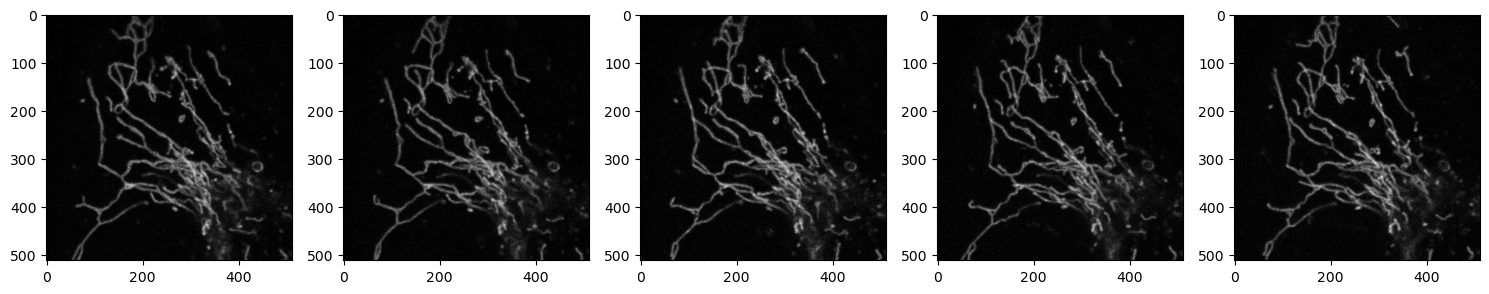

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

t = 0
for i in range(5):
  axes[i].imshow(
    img_frames[t],
    cmap='gray')
  t = t + 35

plt.tight_layout()
plt.show()

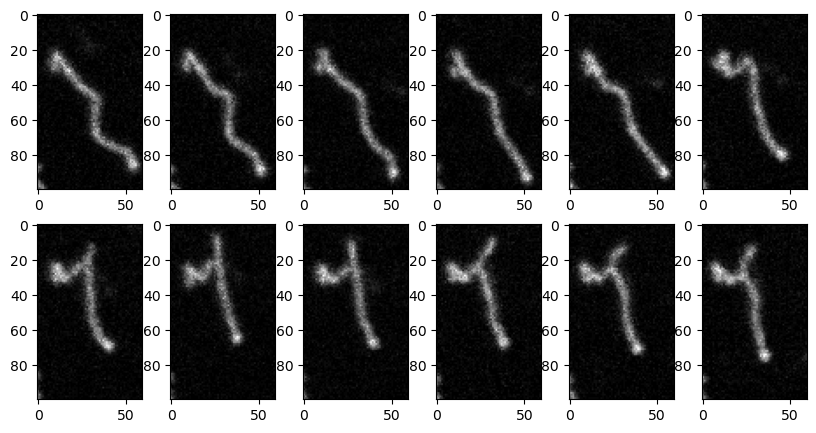

In [6]:
# 1. Define your pixel boundaries
ymin, ymax = 55, 155  
xmin, xmax = 330, 390

roi_1 = img_frames[:,ymin:ymax, xmin:xmax]

fig, axes = plt.subplots(2, 6, figsize=(10, 5))
t_range = range(90, 165, 5)

for idx, ax in enumerate(axes.flat):
  ax.imshow(
    roi_1[t_range[idx]],
    cmap='gray')
  t = t + 15

In [7]:
from skimage.filters import threshold_otsu

threshold = threshold_otsu(roi_1[0])

print("Threshold:", threshold)

Threshold: 8


<Figure size 1000x1000 with 0 Axes>

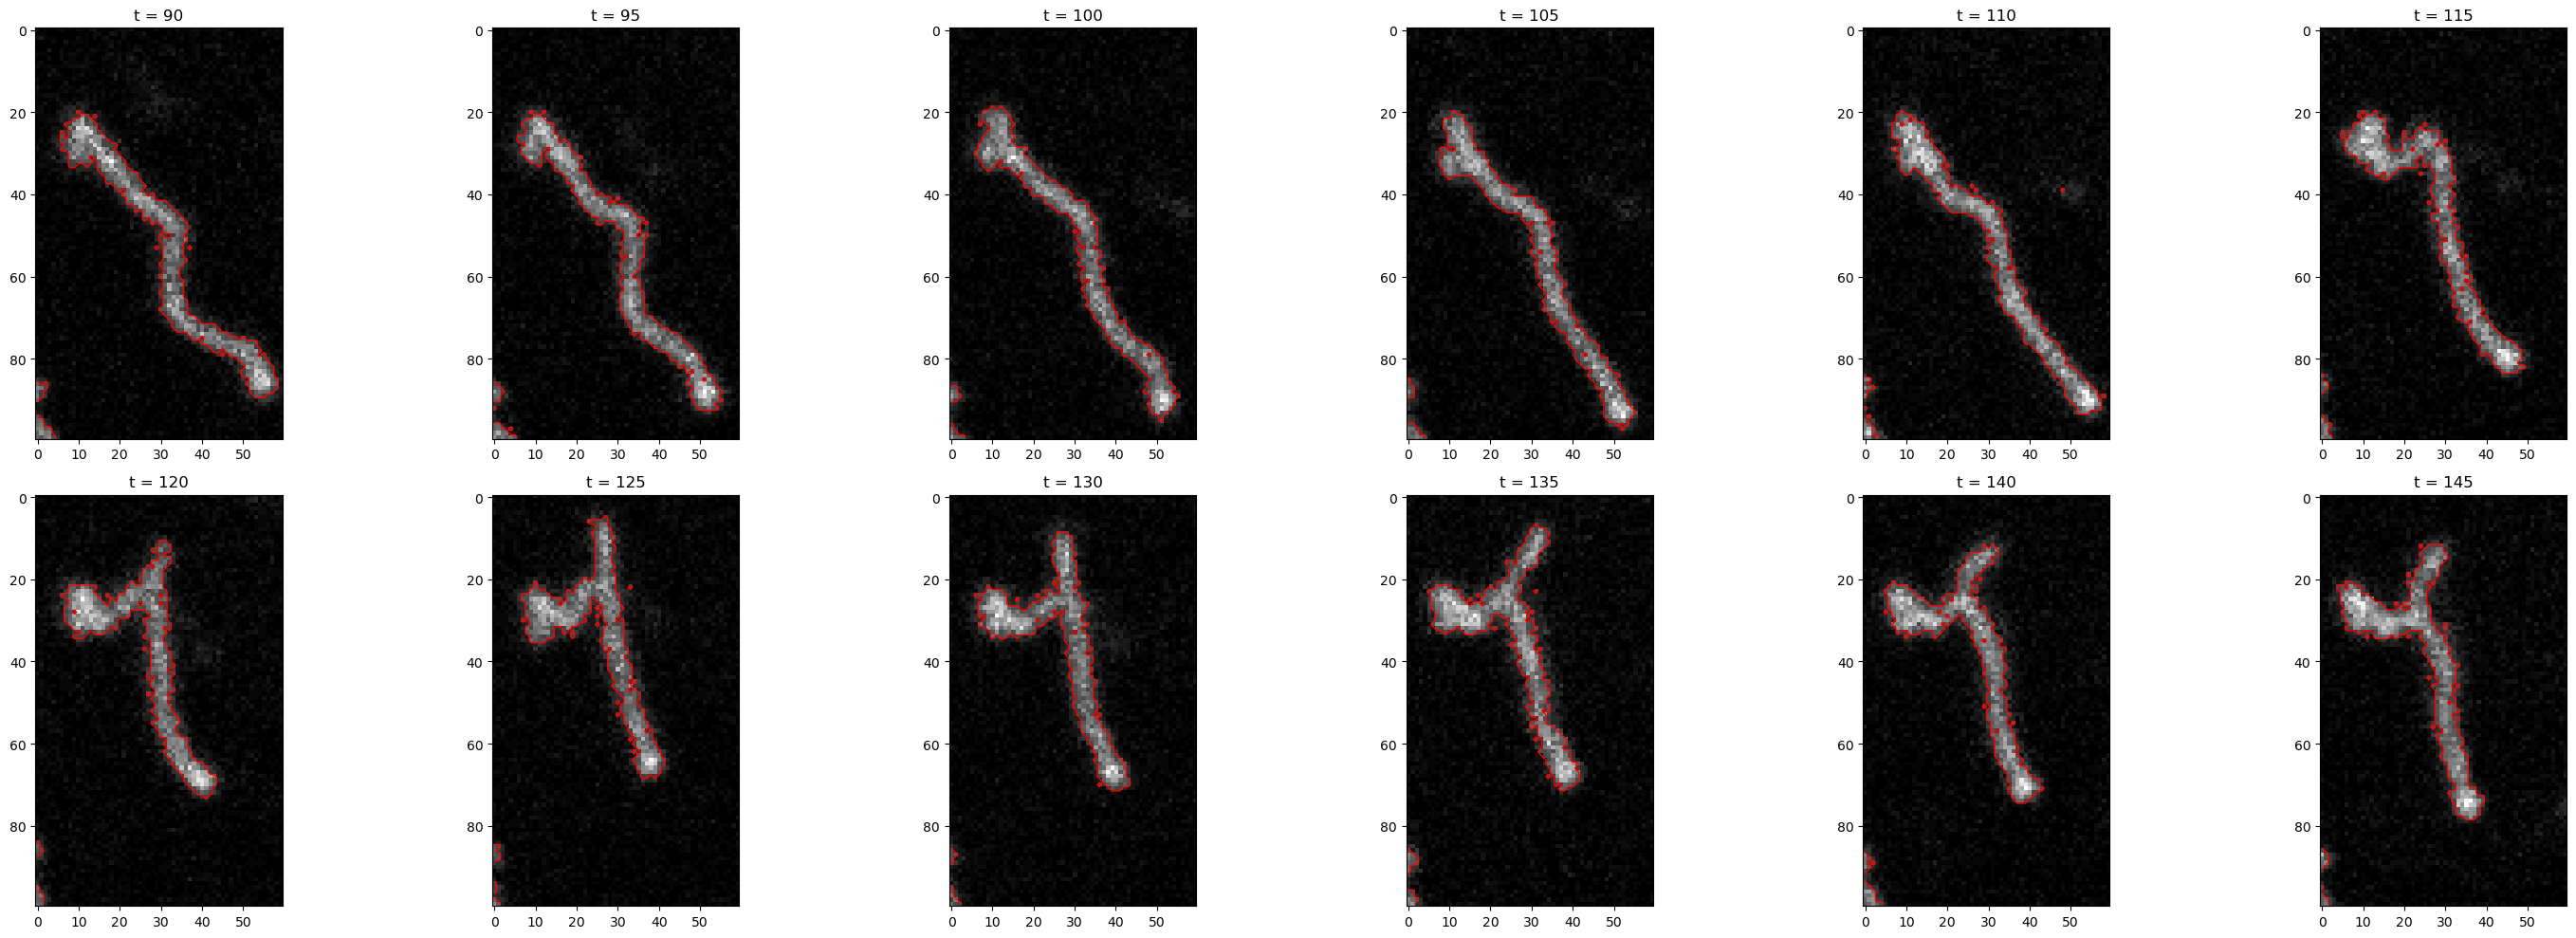

In [8]:
plt.figure(figsize=(10, 10))

# 1. Create the grid
fig, axes = plt.subplots(2, 6, figsize=(30, 10))

t_range = range(90, 165, 5)

# 2. Flatten the axes grid to loop through all 16 subplots sequentially
for idx, ax in enumerate(axes.flat):
    # Calculate time index: 0, 10, 20, 30...
    t = t_range[idx]
    
    # Optional: Prevent IndexError if 't' exceeds the available frames in roi_1
    if t >= len(roi_1):
        ax.axis('off')  # Hide empty remaining subplots
        continue

    # Display the grayscale frame
    ax.imshow(roi_1[t], cmap='gray')
    
    threshold = threshold_otsu(roi_1[t])

    # Apply the threshold mask
    otsu_result_t = roi_1[t] > threshold

    # Draw the red outline contour over the frame
    ax.contour(
        otsu_result_t,
        levels=[0.5],
        colors="red",
        linewidths=1
    )
    
    # Optional: Add a title to each subplot to track timeframes
    ax.set_title(f"t = {t}")

plt.tight_layout()
plt.show()


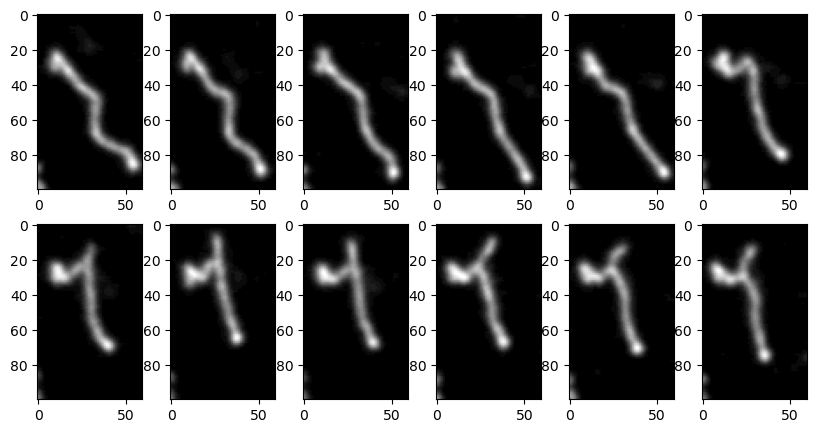

In [9]:
# Suavizando el ruido

roi_1_suavizado = np.zeros(roi_1.shape)
for idx, frame in enumerate(roi_1):
    roi_1_suavizado[idx] = gaussian_filter(frame, sigma=1.5)

fig, axes = plt.subplots(2, 6, figsize=(10, 5))
t_range = range(90, 165, 5)

for idx, ax in enumerate(axes.flat):
  ax.imshow(
    roi_1_suavizado[t_range[idx]],
    cmap='gray')
  t = t + 15


<Figure size 1000x1000 with 0 Axes>

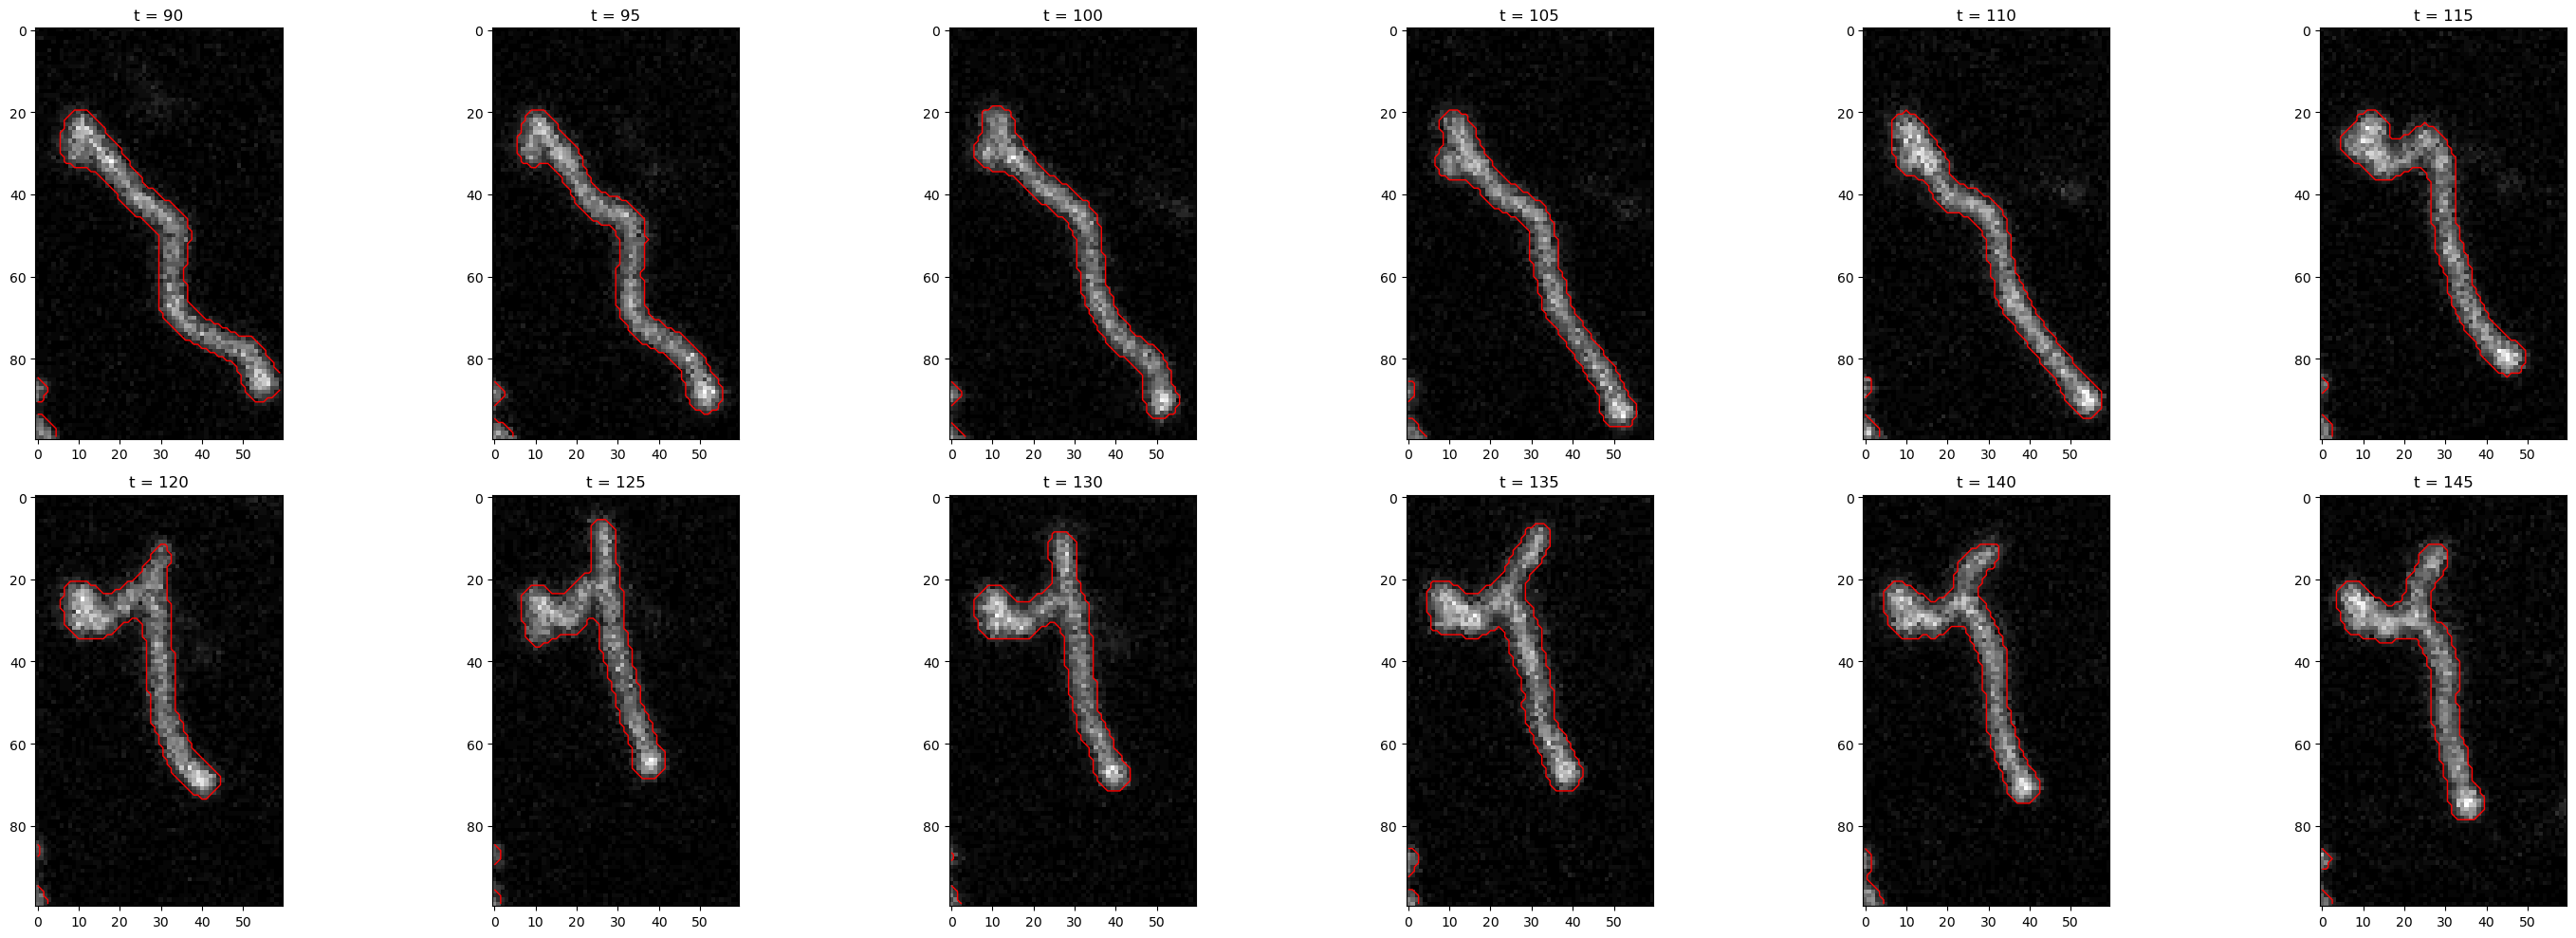

In [10]:
plt.figure(figsize=(10, 10))

# 1. Create the grid
fig, axes = plt.subplots(2, 6, figsize=(30, 10))

t_range = range(90, 165, 5)

otsu_mask = []

# 2. Flatten the axes grid to loop through all 16 subplots sequentially
for idx, ax in enumerate(axes.flat):
    # Calculate time index: 0, 10, 20, 30...
    t = t_range[idx]
    
    # Optional: Prevent IndexError if 't' exceeds the available frames in roi_1
    if t >= len(roi_1):
        ax.axis('off')  # Hide empty remaining subplots
        continue

    # Display the grayscale frame
    ax.imshow(roi_1[t], cmap='gray')
    
    threshold = threshold_otsu(roi_1_suavizado[t])

    # Apply the threshold mask
    otsu_result_t = roi_1_suavizado[t] > threshold

    if t in [110,120,130]:
        otsu_mask.append(otsu_result_t)

    # Draw the red outline contour over the frame
    ax.contour(
        otsu_result_t,
        levels=[0.5],
        colors="red",
        linewidths=1
    )
    
    # Optional: Add a title to each subplot to track timeframes
    ax.set_title(f"t = {t}")

plt.tight_layout()
plt.show()

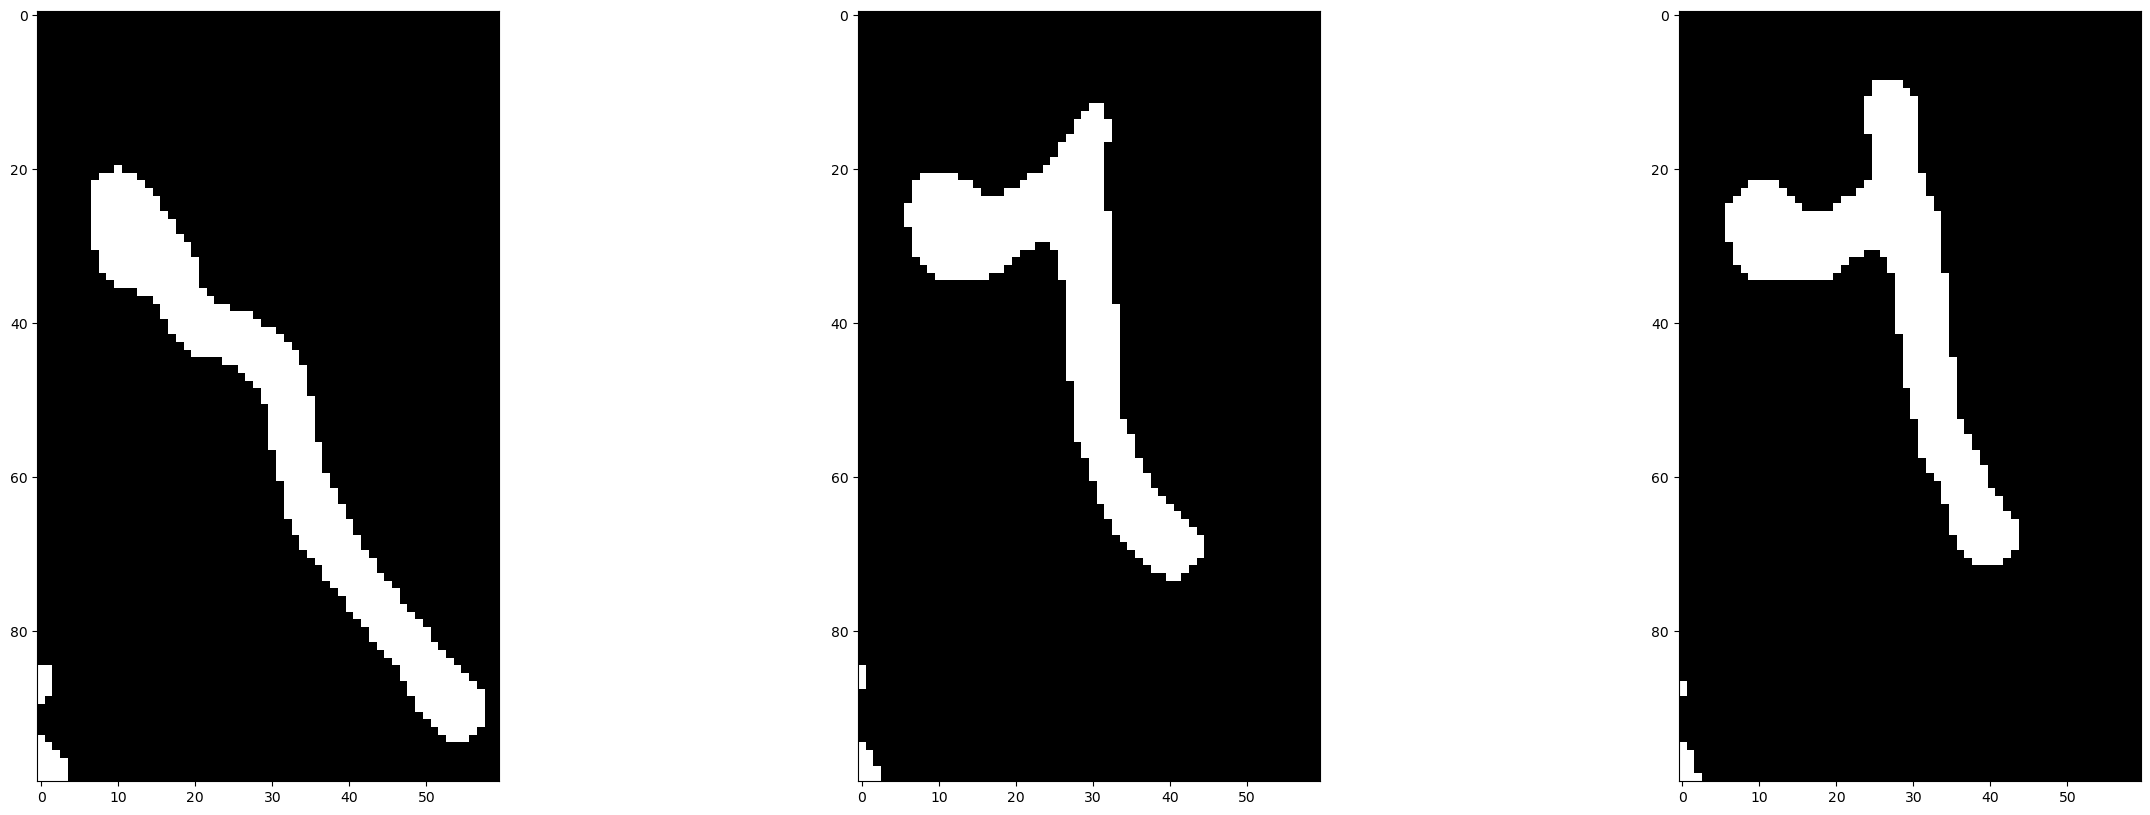

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

# 2. Flatten the axes grid to loop through all 16 subplots sequentially
for idx, ax in enumerate(axes.flat):
    ax.imshow(otsu_mask[idx], cmap='gray')